# Exercise 4.A introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


## Working Through The Sample Script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [5]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [6]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


C:\Users\coreyallen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


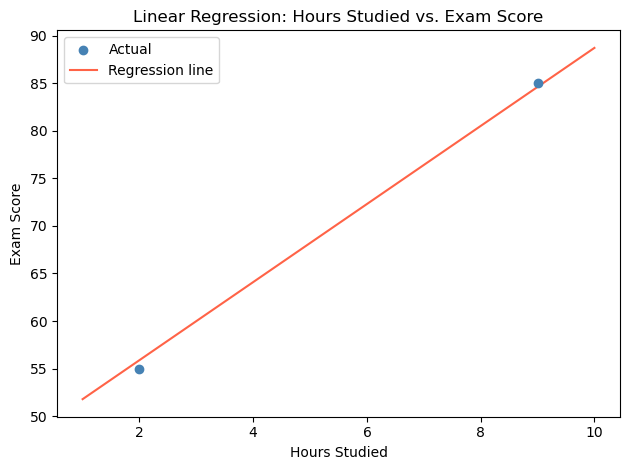

In [7]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

## Lab 2
### Building your own model

In [10]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

In [13]:
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [14]:
# Defining matrix and vector
x2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

In [17]:
# Print
print(f"shape of X2:, {x2.shape}")
print(f"Shape of Y2:, {y2.shape}")

shape of X2:, (20, 1)
Shape of Y2:, (20,)


In [18]:
# Splitting x, y
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

In [19]:
print("X2_train shape:", x2_train.shape)
print("X2_test shape:", x2_test.shape)
print("y2_train shape:", y2_train.shape)
print("y2_test shape:", y2_test.shape)

X2_train shape: (16, 1)
X2_test shape: (4, 1)
y2_train shape: (16,)
y2_test shape: (4,)


In [21]:
# Creating & Training My Techno Underling
model2 = LinearRegression()
model2.fit(x2_train, y2_train)
print("Techno underling will be subordinate for the duration of it's menial existence")

Techno underling will be subordinate for the duration of it's menial existence


In [28]:
# Print slope and intercept
print(f"Slope: {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope: 1.96
Intercept: 3625.89


For each dollar spent on ads, the projected monthly revenue increased by about 1.96.

### Making Predictions and Evaluating the Model

In [31]:
# Test set Prediction
y2_pred = model2.predict(x2_test)

In [32]:
# Projected vs Actual
results = pd.DataFrame({
    'Actual Revenue': y2_test.values,
    'Projected Revenue': y2_pred.round(2)
})

print(results.to_string(index=False))

 Actual Revenue  Projected Revenue
           4200            4603.85
          21500           21229.03
          19400           19273.13
           5100            5581.80


In [33]:
# R SCOREEEE
r2 = model2.score(x2_test, y2_test)
print(f"R Score: {r2:.4f}")

R Score: 0.9981


### Visualizing the Results

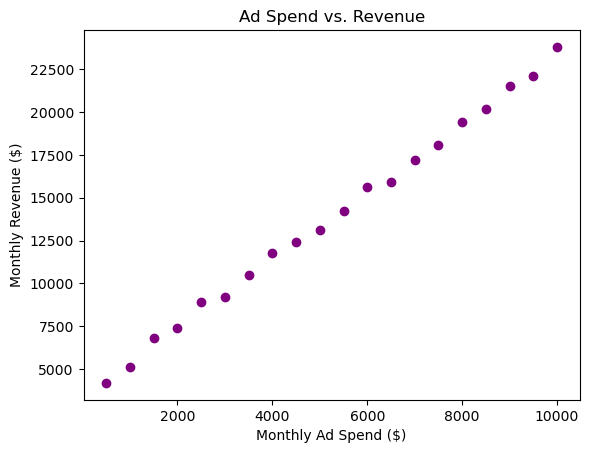

In [40]:
# SCATTERED PLOT
plt.scatter(x2, y2, color='purple')
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.show()

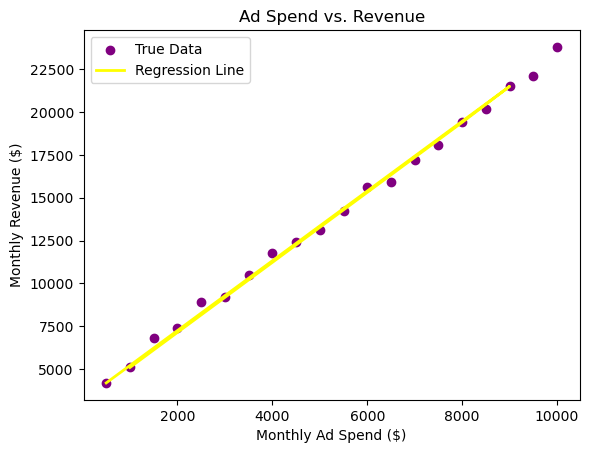

In [45]:
# SCATTERED PLOT + REGRESSION
plt.scatter(x2, y2, color='purple', label='True Data')
plt.plot(x2_test, y2_test, color='yellow', linewidth=2, label='Regression Line')
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.legend()
plt.show()

The regression line accurately reflects the scatter data and is aligned with the R score of 0.99.